# Ames Housing: Analysis, Feature Engineering and Model Selection

**Part one of the Feature Engineering / FastAPI / Streamlit / Databricks project.**

This notebook documents how the raw Kaggle data becomes a model that can be
served. It has one organising principle: every claim is backed by a number
computed here, and where the evidence does not support a claim we say so.

The dataset is the [Home Data for ML Course](https://www.kaggle.com/competitions/home-data-for-ml-course/data)
competition data — 1460 labelled houses in Ames, Iowa, with 79 descriptive
columns and `SalePrice` as the target.

## How to read this notebook

| Section | Question it answers |
|---|---|
| 1 | What is in the data, and what does the target look like? |
| 2 | What is missing, and what does *missing* actually mean here? |
| 3 | Which observations are extreme, and should we act on them? |
| 4 | Which features did we build, and on what reasoning? |
| 5 | Do those features measurably help? |
| 6 | Which model, measured against what baseline? |
| 7 | Does tuning the winner buy anything? |
| 8 | What do these numbers actually prove? |
| 9 | What exactly is handed to the serving layer? |
| 10 | How wrong is it, where, and what should we quote? |
| 11 | Who should use this model, and who should not? |

## Reproducibility

All logic lives in the `src` package and is imported here rather than
restated, so the notebook and the training pipeline cannot drift apart. One
seed governs every source of randomness and the cross-validation split is
fixed, so repeated runs on the same machine give identical results.

Across machines the fourth decimal can move — we have seen log-RMSE 0.1267
and 0.1263 for the same configuration. XGBoost and LightGBM accumulate
gradients in thread-completion order with `n_jobs=-1`, so the sum depends on
how many cores are available. The effect is roughly 0.0004, which is two
orders of magnitude below the spread between folds and therefore irrelevant
to every conclusion drawn here — but it is worth stating rather than
claiming an exactness we do not have.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# The kernel starts in notebooks/, so the project root is not importable
# until we say where it is. Located by walking up to the folder holding src/
# rather than hard-coding "..", so the notebook also runs from the root.
PROJECT_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "src").is_dir()
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import CONFIG
from src.data_cleaning import ABSENCE_COLUMNS, ZERO_FILL_COLUMNS, clean_data
from src.evaluate import SELECTION_METRIC, paired_difference
from src.feature_engineering import create_features
from src.models import PreprocessorStep, available_models, build_model, feature_names
from src.train import compare_models, cross_validate, load_training_data
from src.utils import set_seed

set_seed()

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print(f"seed        : {CONFIG.random_seed}")
print(f"cv folds    : {CONFIG.n_splits}")
print(f"candidates  : {', '.join(available_models())}")

seed        : 42
cv folds    : 5
candidates  : xgboost, lightgbm, random_forest, mlp


---

## 1. The data

`train.csv` carries the label; `test.csv` is the competition's held-out set
and has no `SalePrice`, so it cannot be used to measure anything. Every
score in this notebook therefore comes from cross-validation inside the
training file, and `test.csv` appears only at the end as realistic input for
the serving layer.

In [2]:
features, target = load_training_data()
test_frame = pd.read_csv(CONFIG.test_csv)

print(f"train : {features.shape[0]} rows x {features.shape[1]} columns (+ target)")
print(f"test  : {test_frame.shape[0]} rows x {test_frame.shape[1]} columns (no target)")
print()
print(target.describe().round(0).to_string())

train : 1460 rows x 80 columns (+ target)
test  : 1459 rows x 80 columns (no target)

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0


### The target is skewed, and that decides the metric

Sale prices are bounded below by zero and have a long right tail: a handful
of houses sell for three or four times the median. Fitting on the raw price
lets those few dominate the loss, and an error of $20,000 counts the same
whether the house is worth $80,000 or $600,000 — which is not how anyone
judges a valuation.

Training on `log1p(SalePrice)` makes the model optimise *relative* error
instead, and predictions are converted back with `expm1` before they are
scored or served.

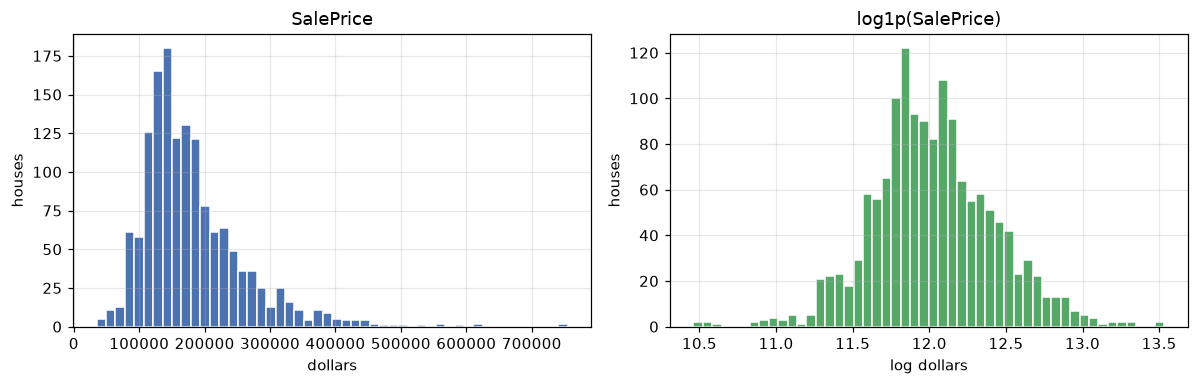

skew, raw price : 1.88
skew, log price : 0.12


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(target, bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("SalePrice")
axes[0].set_xlabel("dollars")

axes[1].hist(np.log1p(target), bins=50, color="#55A868", edgecolor="white")
axes[1].set_title("log1p(SalePrice)")
axes[1].set_xlabel("log dollars")

for axis in axes:
    axis.set_ylabel("houses")

fig.tight_layout()
plt.show()

print(f"skew, raw price : {target.skew():.2f}")
print(f"skew, log price : {np.log1p(target).skew():.2f}")

---

## 2. What is missing, and what does missing mean?

This is the part of the analysis that changed the pipeline most, so it is
worth being precise. A blank cell in this dataset means one of three
different things, and treating them identically produces houses with
basements that do not exist.

In [4]:
missing = features.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

summary = pd.DataFrame(
    {
        "missing": missing,
        "share": (missing / len(features)).map("{:.1%}".format),
    }
)
summary["meaning"] = np.where(
    summary.index.isin(ABSENCE_COLUMNS),
    "absent feature",
    np.where(summary.index.isin(ZERO_FILL_COLUMNS), "absent, numeric", "unknown value"),
)

print(f"{len(missing)} of {features.shape[1]} columns have missing values\n")
summary

19 of 80 columns have missing values



,missing,share,meaning
PoolQC,1453,99.5%,absent feature
MiscFeature,1406,96.3%,absent feature
Alley,1369,93.8%,absent feature
Fence,1179,80.8%,absent feature
MasVnrType,872,59.7%,absent feature
FireplaceQu,690,47.3%,absent feature
LotFrontage,259,17.7%,unknown value
GarageType,81,5.5%,absent feature
GarageYrBlt,81,5.5%,unknown value
GarageFinish,81,5.5%,absent feature


### Three kinds of blank

**Absent, categorical.** `data_description.txt` states it outright: for
`PoolQC`, `Alley`, `GarageType` and others, `NA` means *No Pool*, *No Alley
Access*, *No Garage*. The house is not missing information; it is missing
the thing. These become the literal category `"None"`, which the model can
then learn about like any other category.

**Absent, numeric.** The same logic applies to `TotalBsmtSF`,
`BsmtFullBath`, `MasVnrArea` and friends. A house with no basement has zero
basement square feet, not the median of the houses that have one. Filling
these with a median invents a basement.

**Genuinely unknown.** `LotFrontage` is missing for 259 houses that all
certainly have some frontage; the value simply was not recorded. Only these
are imputed statistically, and only from the training data.

### Why the statistics must be learned, not recomputed

This distinction is not cosmetic. An imputation value computed from whatever
data happens to arrive means the same house scores differently depending on
what it arrives alongside — a request on its own, in a batch of fifty, or in
a full file. That is both a data leak during validation and non-determinism
in production. The imputers are therefore fitted on the training fold and
reused, exactly like the encoder.

In [5]:
absent_examples = ["PoolQC", "Alley", "GarageType", "TotalBsmtSF", "MasVnrArea"]
unknown_examples = ["LotFrontage", "Electrical"]

print("treated as ABSENT (filled with None or 0, no statistics involved)")
for column in absent_examples:
    if column in features.columns:
        print(f"  {column:14} {features[column].isna().sum():4d} missing")

print("\ntreated as UNKNOWN (imputed from training statistics)")
for column in unknown_examples:
    print(f"  {column:14} {features[column].isna().sum():4d} missing")

cleaned = clean_data(features)
print(f"\nremaining blanks after the absence rules: {int(cleaned.isna().sum().sum())}")
print("(these are the genuinely unknown ones, left for the fitted imputer)")

treated as ABSENT (filled with None or 0, no statistics involved)
  PoolQC         1453 missing
  Alley          1369 missing
  GarageType       81 missing
  TotalBsmtSF       0 missing
  MasVnrArea        8 missing

treated as UNKNOWN (imputed from training statistics)
  LotFrontage     259 missing
  Electrical        1 missing

remaining blanks after the absence rules: 341
(these are the genuinely unknown ones, left for the fitted imputer)


---

## 3. Outliers and influential observations

The single most cited plot in this dataset is above-grade living area
against price. It is cited because of what sits in the bottom right.

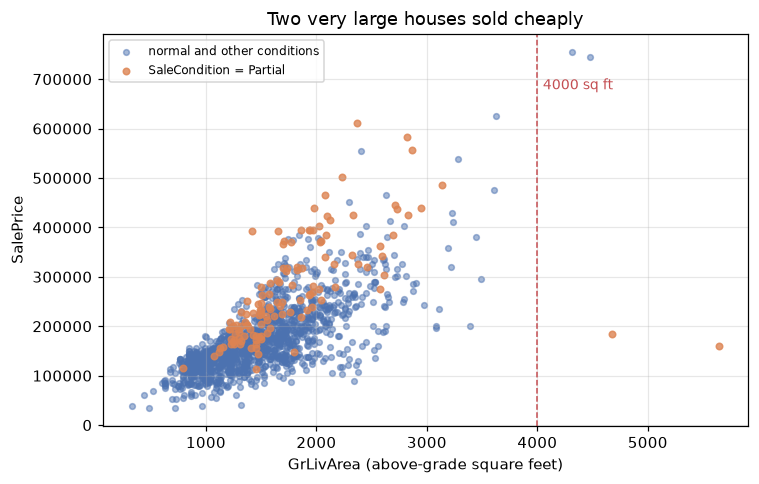

In [6]:
condition = features["SaleCondition"]
is_partial = condition == "Partial"

fig, axis = plt.subplots(figsize=(7, 4.5))

axis.scatter(
    features.loc[~is_partial, "GrLivArea"],
    target[~is_partial],
    s=14, alpha=0.5, color="#4C72B0", label="normal and other conditions",
)
axis.scatter(
    features.loc[is_partial, "GrLivArea"],
    target[is_partial],
    s=18, alpha=0.8, color="#DD8452", label="SaleCondition = Partial",
)
axis.axvline(4000, color="#C44E52", linestyle="--", linewidth=1)
axis.annotate(
    "4000 sq ft", xy=(4050, target.max() * 0.9), color="#C44E52", fontsize=9
)
axis.set_xlabel("GrLivArea (above-grade square feet)")
axis.set_ylabel("SalePrice")
axis.set_title("Two very large houses sold cheaply")
axis.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [7]:
large = features["GrLivArea"] > 4000
extreme = pd.DataFrame(
    {
        "GrLivArea": features.loc[large, "GrLivArea"],
        "SalePrice": target[large],
        "OverallQual": features.loc[large, "OverallQual"],
        "SaleCondition": features.loc[large, "SaleCondition"],
        "YearBuilt": features.loc[large, "YearBuilt"],
    }
).sort_values("SalePrice")

print(f"{large.sum()} houses exceed 4000 square feet\n")
print(extreme.to_string())
print(f"\nmedian price of all houses: ${target.median():,.0f}")

4 houses exceed 4000 square feet

      GrLivArea  SalePrice  OverallQual SaleCondition  YearBuilt
1298       5642     160000           10       Partial       2008
523        4676     184750           10       Partial       2007
1182       4476     745000           10       Abnorml       1996
691        4316     755000           10        Normal       1994

median price of all houses: $163,000


### What the extreme rows actually are

Two of these houses are enormous and sold for less than the median. That is
not a data-entry error and it is not a mysterious market event: their
`SaleCondition` is `Partial`, which `data_description.txt` defines as *Home
was not completed when last assessed*. The price recorded is not the price
of a finished house, so for those rows the target is not measuring the same
quantity as it is everywhere else.

### The tempting mistake

The common recipe is to drop everything above 4000 square feet, and it does
improve the cross-validation score. It is still the wrong reasoning, for two
reasons.

**It filters on the outcome.** "Large area, low price" is a description of
where the model has large residuals. Removing rows because the model finds
them hard, then reporting that the model does better, is circular. The score
improves on a dataset we curated to make it improve.

**The information is already available.** `SaleCondition` is one of the 79
input columns. The model can learn that `Partial` sales behave differently
without us deleting anything — and at prediction time it will meet such
houses again, whether or not they were in training.

Removing rows for a *documented* reason is defensible; removing them because
they are inconvenient is not. Below we measure what the removal would buy,
so the decision rests on a number rather than a preference.

In [8]:
# What would dropping the two partial mega-sales actually change?
drop_mask = (features["GrLivArea"] > 4000) & (features["SaleCondition"] == "Partial")

trimmed_features = features[~drop_mask]
trimmed_target = target[~drop_mask]

full = cross_validate("xgboost", features, target, CONFIG.n_splits)
trimmed = cross_validate("xgboost", trimmed_features, trimmed_target, CONFIG.n_splits)

full_score = np.mean([f.rmse_log for f in full.folds])
trimmed_score = np.mean([f.rmse_log for f in trimmed.folds])

print(f"rows removed            : {int(drop_mask.sum())}")
print(f"log-RMSE, all rows      : {full_score:.4f}")
print(f"log-RMSE, without them  : {trimmed_score:.4f}")
print(f"apparent improvement    : {full_score - trimmed_score:+.4f}")
print()
print("Not a paired comparison: the two runs score different row sets, so the")
print("second number is measured on an easier problem. That is precisely why")
print("the improvement cannot be taken at face value.")

21:59:37 | INFO    | train | xgboost (fe) fold 1/5: rmse_log=0.1310 rmse=$25,898


21:59:38 | INFO    | train | xgboost (fe) fold 2/5: rmse_log=0.1129 rmse=$27,405


21:59:40 | INFO    | train | xgboost (fe) fold 3/5: rmse_log=0.1577 rmse=$41,847


21:59:43 | INFO    | train | xgboost (fe) fold 4/5: rmse_log=0.1214 rmse=$25,363


21:59:45 | INFO    | train | xgboost (fe) fold 5/5: rmse_log=0.1103 rmse=$20,190


...

21:59:49 | INFO    | train | xgboost (fe) fold 2/5: rmse_log=0.1090 rmse=$21,983


21:59:51 | INFO    | train | xgboost (fe) fold 3/5: rmse_log=0.1199 rmse=$20,600


21:59:52 | INFO    | train | xgboost (fe) fold 4/5: rmse_log=0.1225 rmse=$24,649


21:59:54 | INFO    | train | xgboost (fe) fold 5/5: rmse_log=0.1145 rmse=$24,635


rows removed            : 2
log-RMSE, all rows      : 0.1267
log-RMSE, without them  : 0.1167
apparent improvement    : +0.0100

Not a paired comparison: the two runs score different row sets, so the
second number is measured on an easier problem. That is precisely why
the improvement cannot be taken at face value.


The score does improve — and it improves *because we removed the hard rows
from the test folds as well as the training folds*. The second number
answers a different question than the first, so the difference is not
evidence of a better model.

**Decision: keep every row.** `SaleCondition` gives the model what it needs
to treat partial sales differently, and a model that has never seen an
unfinished house will meet one eventually. We record the analysis rather
than the deletion.

### Where the model actually struggles

Fold 3 is consistently the hardest fold for all four candidates. It is worth
checking whether that is the extreme rows or something else.

In [9]:
from sklearn.model_selection import KFold

splitter = KFold(
    n_splits=CONFIG.n_splits, shuffle=True, random_state=CONFIG.random_seed
)

rows = []

for number, (_, valid_index) in enumerate(splitter.split(features), 1):
    holdout = target.iloc[valid_index]

    rows.append(
        {
            "fold": number,
            "n": len(valid_index),
            "median price": holdout.median(),
            "max price": holdout.max(),
            "price std": holdout.std(),
            "above $400k": int((holdout > 400_000).sum()),
        }
    )

fold_profile = pd.DataFrame(rows).set_index("fold")
print("Fold 3 was hardest for every model. Its hold-out set:\n")
fold_profile.round(0)

Fold 3 was hardest for every model. Its hold-out set:



,n,median price,max price,price std,above $400k
fold,,,,,
1,292,154150.0,755000,87731.0,7
2,292,167500.0,745000,82599.0,8
3,292,168250.0,625000,74456.0,4
4,292,160000.0,582933,79377.0,6
5,292,163750.0,538000,72421.0,3


Fold 3 holds more of the expensive tail than the others. Expensive houses
are rarer, so the model has seen fewer like them, and log-scale errors on
them are larger. This is a property of the data and the split, not a defect
in any candidate — which is exactly why the paired comparison in section 5
matters: that shared difficulty cancels when the same fold is differenced
against itself.

---

## 4. The features we built

Nine features are derived from the raw columns. Each one encodes a
relationship a human appraiser would use, expressed so the model does not
have to discover it from scratch.

| Feature | Definition | Reasoning |
|---|---|---|
| `TotalSF` | basement + 1st + 2nd floor | Buyers price total liveable space, not floors separately |
| `TotalBath` | full + ½·half, above and below grade | One number for sanitary capacity; a half bath is worth less than a full one |
| `TotalPorchSF` | five porch and deck columns | Individually sparse, jointly meaningful outdoor space |
| `HouseAge` | `YrSold − YearBuilt` | Age at the moment of sale, which is what the price reflects |
| `RemodAge` | `YrSold − YearRemodAdd` | Recency of renovation, separate from original age |
| `IsRemodeled` | `YearRemodAdd > YearBuilt` | Whether a renovation happened at all |
| `HasGarage` | `GarageType != "None"` | Presence, independent of recorded size |
| `HasBasement` | `TotalBsmtSF > 0` | Presence, independent of recorded size |
| `HasFireplace` | `Fireplaces > 0` | Presence, independent of count |

In [10]:
engineered = create_features(cleaned)
new_columns = [c for c in engineered.columns if c not in cleaned.columns]

print(f"{len(new_columns)} derived features: {', '.join(new_columns)}\n")
engineered[new_columns].head()

9 derived features: TotalSF, TotalBath, TotalPorchSF, HouseAge, RemodAge, IsRemodeled, HasGarage, HasBasement, HasFireplace



,TotalSF,TotalBath,TotalPorchSF,HouseAge,RemodAge,IsRemodeled,HasGarage,HasBasement,HasFireplace
0,2566,3.5,61,5,5,0,1,1,0
1,2524,2.5,298,31,31,0,1,1,1
2,2706,3.5,42,7,6,1,1,1,1
3,2473,2.0,307,91,36,1,1,1,1
4,3343,3.5,276,8,8,0,1,1,1


### A concrete lesson: presence is not size

`HasGarage` was first written as `GarageArea > 0`. That is wrong, and the
data shows exactly why. One house in the test set has a missing
`GarageArea` — but its `GarageType` is `Detchd`. The garage exists; only its
size went unrecorded. Deriving presence from the size column would have
labelled that house as having no garage, and would have done so again for
every future request where a size field was left blank.

`GarageType` carries the documented `NA = No Garage` meaning, so presence is
read from there instead. The same principle underlies the split in section
2: read a fact from the column that actually states it.

In [11]:
missing_area = test_frame[test_frame["GarageArea"].isna()]

print("Test-set houses with no recorded GarageArea:")
print(
    missing_area[["Id", "GarageType", "GarageYrBlt", "GarageCars", "GarageArea"]]
    .to_string(index=False)
)

print("\nGarageType is present, so the garage exists and the size is simply unknown.")
print("Reading presence from GarageArea would have called this house garage-less.")

Test-set houses with no recorded GarageArea:
  Id GarageType  GarageYrBlt  GarageCars  GarageArea
2577     Detchd          NaN         NaN         NaN

GarageType is present, so the garage exists and the size is simply unknown.
Reading presence from GarageArea would have called this house garage-less.


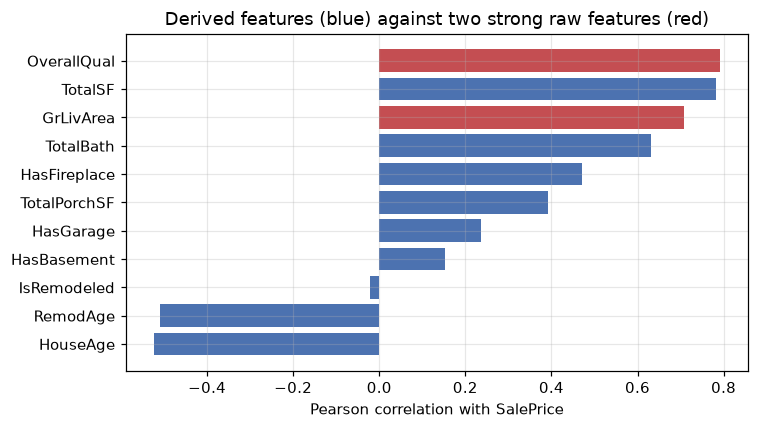

In [12]:
correlations = (
    engineered[new_columns + ["OverallQual", "GrLivArea"]]
    .assign(SalePrice=target.values)
    .corr()["SalePrice"]
    .drop("SalePrice")
    .sort_values()
)

fig, axis = plt.subplots(figsize=(7, 4))
colours = ["#C44E52" if c not in new_columns else "#4C72B0" for c in correlations.index]
axis.barh(correlations.index, correlations.values, color=colours)
axis.set_xlabel("Pearson correlation with SalePrice")
axis.set_title("Derived features (blue) against two strong raw features (red)")
fig.tight_layout()
plt.show()

`TotalSF` correlates with price about as strongly as `OverallQual`, the
single best raw predictor. That is encouraging — but correlation with the
target is not evidence that a feature *adds* anything, because the columns it
is built from are already available to the model. The next section tests
that properly.

---

## 5. Do the derived features actually help?

A feature that correlates with the target may still be redundant: a
gradient-boosted tree can approximate `TotalSF` by splitting on its three
components. The only way to know is to remove the features and measure.

### How the comparison is designed

Both variants are scored over **the same** cross-validation split. This
matters more than it looks. Fold 3 of this dataset is harder than the others
for every model we tried, and that shared difficulty dominates the spread
between folds. If each variant made its own split, part of any difference we
measured would simply be the split.

Because the folds are shared, the two runs are **paired samples**. The right
comparison is therefore the difference *within each fold*, averaged, with
the standard error of that average — not the two means each judged against
its own spread. Differencing inside a fold cancels the shared difficulty on
both sides at once, and on this data it produces an interval several times
tighter.

In [13]:
# Around two minutes: four candidates, two variants, five folds each.
ablation = compare_models(variants=("fe", "nofe"))
ablation[["model", "rmse_log_mean", "rmse_log_std", "rmse_mean", "r2_mean"]].round(4)

21:59:54 | INFO    | train | cross-validating xgboost (fe)


21:59:56 | INFO    | train | xgboost (fe) fold 1/5: rmse_log=0.1310 rmse=$25,898


21:59:58 | INFO    | train | xgboost (fe) fold 2/5: rmse_log=0.1129 rmse=$27,405


22:00:00 | INFO    | train | xgboost (fe) fold 3/5: rmse_log=0.1577 rmse=$41,847


22:00:02 | INFO    | train | xgboost (fe) fold 4/5: rmse_log=0.1214 rmse=$25,363


...

22:01:33 | INFO    | train | mlp (nofe) fold 2/5: rmse_log=0.1445 rmse=$27,873


22:01:39 | INFO    | train | mlp (nofe) fold 3/5: rmse_log=0.2260 rmse=$131,276


22:01:46 | INFO    | train | mlp (nofe) fold 4/5: rmse_log=0.1591 rmse=$31,420


22:01:53 | INFO    | train | mlp (nofe) fold 5/5: rmse_log=0.1351 rmse=$22,373


,model,rmse_log_mean,rmse_log_std,rmse_mean,r2_mean
0,xgboost (fe),0.1267,0.0171,28140.5356,0.8609
1,xgboost (nofe),0.1280,0.0210,29275.4958,0.8447
2,lightgbm (fe),0.1313,0.0213,29042.6165,0.8462
3,lightgbm (nofe),0.1314,0.0219,29280.8552,0.8431
4,random_forest (fe),0.1432,0.0147,31610.6452,0.8370
5,random_forest (nofe),0.1458,0.0148,32284.0132,0.8313
6,mlp (nofe),0.1679,0.0320,49018.4470,0.2757
7,mlp (fe),0.1712,0.0322,54300.4327,-0.0180


In [14]:
rows = []

for name in available_models():
    with_fe = cross_validate(name, features, target, CONFIG.n_splits, "fe")
    without = cross_validate(name, features, target, CONFIG.n_splits, "nofe")

    result = paired_difference(without.folds, with_fe.folds)

    rows.append(
        {
            "model": name,
            "with FE": np.mean([f.rmse_log for f in with_fe.folds]),
            "without FE": np.mean([f.rmse_log for f in without.folds]),
            "difference": result.mean,
            "95% CI": f"[{result.ci_low:+.4f}, {result.ci_high:+.4f}]",
            "separated": result.separated,
        }
    )

paired = pd.DataFrame(rows).set_index("model")
print("A positive difference means feature engineering lowered the error.\n")
paired.round(4)

22:01:55 | INFO    | train | xgboost (fe) fold 1/5: rmse_log=0.1310 rmse=$25,898


22:01:57 | INFO    | train | xgboost (fe) fold 2/5: rmse_log=0.1129 rmse=$27,405


22:01:59 | INFO    | train | xgboost (fe) fold 3/5: rmse_log=0.1577 rmse=$41,847


22:02:00 | INFO    | train | xgboost (fe) fold 4/5: rmse_log=0.1214 rmse=$25,363


22:02:02 | INFO    | train | xgboost (fe) fold 5/5: rmse_log=0.1103 rmse=$20,190


...

22:03:34 | INFO    | train | mlp (nofe) fold 3/5: rmse_log=0.2260 rmse=$131,276


22:03:41 | INFO    | train | mlp (nofe) fold 4/5: rmse_log=0.1591 rmse=$31,420


22:03:47 | INFO    | train | mlp (nofe) fold 5/5: rmse_log=0.1351 rmse=$22,373


A positive difference means feature engineering lowered the error.



,with FE,without FE,difference,95% CI,separated
model,,,,,
xgboost,0.1267,0.1280,0.0013,"[-0.0047, +0.0073]",False
lightgbm,0.1313,0.1314,0.0001,"[-0.0029, +0.0030]",False
random_forest,0.1432,0.1458,0.0025,"[-0.0012, +0.0063]",False
mlp,0.1712,0.1679,-0.0033,"[-0.0223, +0.0158]",False


### The honest answer: no measurable benefit

Every confidence interval includes zero. On this dataset, with this design,
**we cannot demonstrate that the derived features improve accuracy.** The
largest effect is on Random Forest, and even there the interval crosses zero.

Two things are worth adding rather than hiding.

First, the sign is positive for all three tree models, and in four of five
folds for two of them. A small benefit is plausible; five folds simply lack
the power to confirm it. Repeating the cross-validation three times would
give fifteen pairs and narrow the interval by roughly a factor of 1.7.

Second, and more interesting: this is the expected result. `TotalSF` is the
sum of three columns the model already sees, and a tree can build that
relationship from splits. The derived features are not adding information —
they are *reorganising* it.

### So why keep them?

Because accuracy is not their only job. `HouseAge` and `TotalBath` are
quantities a person can reason about and challenge; `YrSold` minus
`YearBuilt` spread across two columns is not. The features make the model
explainable to whoever has to defend a valuation, at no measurable cost.

That is a defensible reason to keep them. "They improved the score" would
not have been, on this evidence.

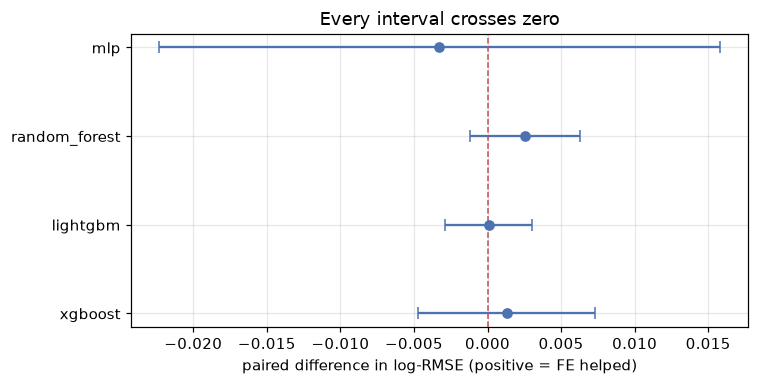

In [15]:
fig, axis = plt.subplots(figsize=(7, 3.6))

positions = np.arange(len(paired))
axis.errorbar(
    paired["difference"],
    positions,
    xerr=[
        paired["difference"] - [float(v.split(",")[0][1:]) for v in paired["95% CI"]],
        [float(v.split(",")[1][:-1]) for v in paired["95% CI"]] - paired["difference"],
    ],
    fmt="o",
    capsize=4,
    color="#4C72B0",
)
axis.axvline(0, color="#C44E52", linestyle="--", linewidth=1)
axis.set_yticks(positions)
axis.set_yticklabels(paired.index)
axis.set_xlabel("paired difference in log-RMSE (positive = FE helped)")
axis.set_title("Every interval crosses zero")
fig.tight_layout()
plt.show()

---

## 6. Choosing a model

### First, what does "good" mean?

A log-RMSE of 0.127 is meaningless without something to compare it to. Two
reference points, both scored over the same folds as everything else:

- **Predict the mean.** The score any model must beat to have learned
  anything at all.
- **Ridge regression** on the same encoded features. A linear model with the
  identical preprocessing, which separates the value of the *features* from
  the value of the *algorithm*.

### Why cross-validation rather than one hold-out split

With 1460 rows, a single 80/20 split moves the score by more than the gap
between candidates. The winner of one split would partly be the winner of
one lucky seed. Five folds give a mean *and* a spread, and the spread is
what tells us whether a ranking means anything.

### Why log-RMSE decides

Log-RMSE is the competition metric, and it treats a proportional error the
same at every price level, which is what makes it right for *comparing*
models. Dollar RMSE and MAE are reported alongside because they are what a
person actually understands.

### Why gradient boosting, before we even measure

Three properties of this dataset point at trees, and specifically at boosted
trees:

- The relationships are **non-linear and interactive**. Quality matters more
  in a large house than a small one; a finished basement adds more in some
  neighbourhoods than others. Trees represent interactions by construction;
  a linear model needs them written out by hand.
- The inputs are **mixed and unscaled** — 43 categorical columns beside
  areas in the thousands and counts in single digits. Trees split on order,
  not distance, so they are indifferent to units and to monotone transforms.
- The dataset is **small and wide** after encoding: 1460 rows against 325
  columns. Boosting with shallow trees and strong regularisation handles
  that ratio better than a deep network, which is why the MLP is included as
  a control rather than a serious contender.

The comparison below tests that reasoning rather than assuming it.

In [16]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

from src.evaluate import RegressionMetrics
from sklearn.model_selection import KFold


def score_baseline(estimator, label, scale=False):
    """Cross-validate a reference model over the project's fixed folds.

    Defined here rather than in src/models.py on purpose: these are analysis
    baselines, not shipping candidates, and adding them to the registry
    would put them in every training run.
    """

    splitter = KFold(
        n_splits=CONFIG.n_splits, shuffle=True, random_state=CONFIG.random_seed
    )
    scores = []

    for train_index, valid_index in splitter.split(features):
        steps = [("preprocessor", PreprocessorStep())]

        if scale:
            steps.append(("scaler", MinMaxScaler()))

        steps.append(("regressor", estimator))

        model = TransformedTargetRegressor(
            regressor=Pipeline(steps), func=np.log1p, inverse_func=np.expm1
        )
        model.fit(features.iloc[train_index], target.iloc[train_index])

        scores.append(
            RegressionMetrics.from_predictions(
                target.iloc[valid_index], model.predict(features.iloc[valid_index])
            )
        )

    print(f"{label:22} log-RMSE {np.mean([s.rmse_log for s in scores]):.4f}")

    return scores


mean_baseline = score_baseline(DummyRegressor(strategy="mean"), "predict the mean")
ridge_baseline = score_baseline(Ridge(alpha=10.0), "ridge regression", scale=True)

predict the mean       log-RMSE 0.3988


ridge regression       log-RMSE 0.1468


### And the baseline a person would actually use

Before any of this existed, someone valuing a house would multiply its size
by a local price per square foot. That rule of thumb is the real competition
— beating the mean proves nothing, beating an appraiser's arithmetic is the
first result worth reporting.

In [17]:
rule_scores = []

for train_index, valid_index in KFold(
    n_splits=CONFIG.n_splits, shuffle=True, random_state=CONFIG.random_seed
).split(features):
    # Median price per square foot, learned from the training fold only.
    rate = (
        target.iloc[train_index] / features.iloc[train_index]["GrLivArea"]
    ).median()

    predicted = features.iloc[valid_index]["GrLivArea"] * rate

    rule_scores.append(
        RegressionMetrics.from_predictions(target.iloc[valid_index], predicted)
    )

print(
    f"{'price per square foot':22} log-RMSE "
    f"{np.mean([s.rmse_log for s in rule_scores]):.4f}   "
    f"(${np.mean([s.mae for s in rule_scores]):,.0f} mean absolute error)"
)

price per square foot  log-RMSE 0.2776   ($38,508 mean absolute error)


In [18]:
comparison = ablation[ablation["model"].str.endswith("(fe)")].copy()
comparison["model"] = comparison["model"].str.replace(" (fe)", "", regex=False)
comparison = comparison.set_index("model")

display = pd.DataFrame(
    {
        "log-RMSE": comparison["rmse_log_mean"].round(4),
        "std": comparison["rmse_log_std"].round(4),
        "RMSE $": comparison["rmse_mean"].round(0),
        "MAE $": comparison["mae_mean"].round(0),
        "R2": comparison["r2_mean"].round(3),
    }
)
display

,log-RMSE,std,RMSE $,MAE $,R2
model,,,,,
xgboost,0.1267,0.0171,28141.0,14867.0,0.861
lightgbm,0.1313,0.0213,29043.0,15559.0,0.846
random_forest,0.1432,0.0147,31611.0,17211.0,0.837
mlp,0.1712,0.0322,54300.0,20584.0,-0.018


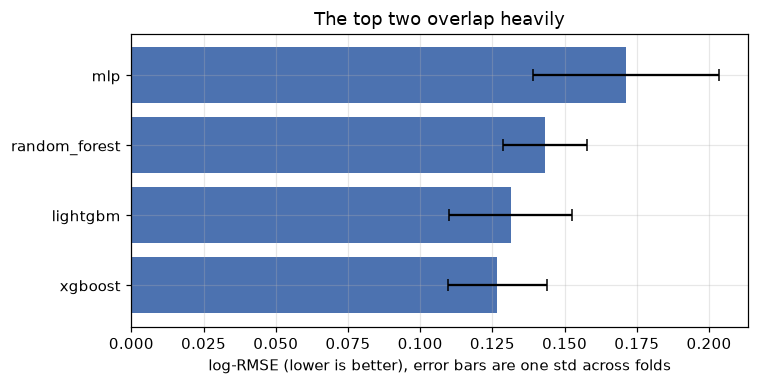

In [19]:
fig, axis = plt.subplots(figsize=(7, 3.6))

axis.barh(
    comparison.index,
    comparison["rmse_log_mean"],
    xerr=comparison["rmse_log_std"],
    color="#4C72B0",
    capsize=4,
)
axis.set_xlabel("log-RMSE (lower is better), error bars are one std across folds")
axis.set_title("The top two overlap heavily")
fig.tight_layout()
plt.show()

### What the baselines tell us

Three reference points, and the ordering matters more than any single
number:

| | log-RMSE |
|---|---|
| predict the mean | 0.399 |
| price per square foot | 0.278 |
| ridge on the encoded features | 0.147 |
| XGBoost | 0.127 |

The appraiser's rule of thumb beats the mean by a wide margin, and a linear
model on our encoded features beats the rule of thumb by more. **Most of the
distance from 0.40 to 0.13 is covered before any tree is grown** — it comes
from the preprocessing decisions in sections 2 and 4, not from the
algorithm.

But the last step is not noise either. XGBoost improves on Ridge by 0.020,
which is larger than the 0.017 spread between folds — and that makes it one
of the few differences in this entire notebook big enough to be real. The
feature ablation, the hyperparameter search and the gap between XGBoost and
LightGBM all failed that test. The gap to a linear model passes it.

### Reading the result honestly

XGBoost has the lowest error and is the model we ship. But its lead over
LightGBM is roughly 0.005 while the spread between folds is around 0.02 —
the two are **not separated by this evidence**, and a different split could
reverse them. Random Forest sits about one standard deviation behind, which
is a weak but more consistent gap.

The neural network finishes last, which is the expected outcome for tabular
data with 1460 rows. Its dollar RMSE is far worse than its MAE, meaning it
is not uniformly weaker but occasionally very wrong, and its negative R² on
the dollar scale says that in those terms it loses to predicting the mean.

One implementation detail is worth recording, because it cost real time: the
network was initially scored with standardised inputs and produced garbage
(log-RMSE 0.88). Most of the 325 encoded columns are one-hot dummies, and
standardising a category seen once in 1460 rows sends that column to 34
standard deviations, which is enough to destabilise the first layer.
Min-max scaling keeps the dummies at 0/1 and brought the same network to
0.14. Only the network is scaled; trees split on raw values and gain
nothing from it.

---

## 7. Does tuning the winner buy anything?

The hyperparameters used so far were chosen by hand for a small dataset:
shallow trees, few leaves, subsampling on. That is a defensible starting
point, not an optimised one. This section searches properly and measures
what the search is worth.

### How the search avoids fooling us

A randomised search over 20 configurations, each scored by 3-fold
cross-validation *inside* the search. The winning configuration is then
re-scored over the project's usual 5 folds and compared to the default
configuration **on those same folds**, so the comparison is paired exactly
like the feature ablation.

One caveat is stated rather than hidden: the search saw every training row,
so its own `best_score_` is optimistically biased by selection. A fully
rigorous estimate needs nested cross-validation, which costs roughly twenty
times the compute for a question this small. The paired re-score below is
the honest number to read.

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

search_space = {
    "regressor__regressor__max_depth": [3, 4, 5, 6],
    "regressor__regressor__learning_rate": [0.02, 0.05, 0.1],
    "regressor__regressor__n_estimators": [400, 600, 900],
    "regressor__regressor__subsample": [0.6, 0.8, 1.0],
    "regressor__regressor__colsample_bytree": [0.6, 0.8, 1.0],
    "regressor__regressor__min_child_weight": [1, 2, 5],
    "regressor__regressor__reg_lambda": [0.5, 1.0, 5.0],
}

search = RandomizedSearchCV(
    build_model("xgboost"),
    param_distributions=search_space,
    n_iter=20,
    cv=KFold(n_splits=3, shuffle=True, random_state=CONFIG.random_seed),
    scoring="neg_root_mean_squared_error",
    random_state=CONFIG.random_seed,
    n_jobs=1,
    refit=False,
)

# A few minutes: 20 configurations, 3 folds each.
search.fit(features, np.log1p(target))

best = {k.split("__")[-1]: v for k, v in search.best_params_.items()}

print("best configuration found:")
for key, value in sorted(best.items()):
    print(f"  {key:20} {value}")
print(f"\ninner 3-fold score (optimistic): {-search.best_score_:.4f}")

best configuration found:
  colsample_bytree     0.6
  learning_rate        0.05
  max_depth            3
  min_child_weight     1
  n_estimators         400
  reg_lambda           5.0
  subsample            0.6

inner 3-fold score (optimistic): 0.1283


In [21]:
def score_xgboost(params, label):
    """Score one XGBoost configuration over the project's fixed folds."""

    splitter = KFold(
        n_splits=CONFIG.n_splits, shuffle=True, random_state=CONFIG.random_seed
    )
    scores = []

    for train_index, valid_index in splitter.split(features):
        model = TransformedTargetRegressor(
            regressor=Pipeline(
                [
                    ("preprocessor", PreprocessorStep()),
                    (
                        "regressor",
                        XGBRegressor(
                            random_state=CONFIG.random_seed, n_jobs=-1, **params
                        ),
                    ),
                ]
            ),
            func=np.log1p,
            inverse_func=np.expm1,
        )
        model.fit(features.iloc[train_index], target.iloc[train_index])

        scores.append(
            RegressionMetrics.from_predictions(
                target.iloc[valid_index], model.predict(features.iloc[valid_index])
            )
        )

    print(f"{label:22} log-RMSE {np.mean([s.rmse_log for s in scores]):.4f}")

    return scores


default_params = {
    "n_estimators": 600, "learning_rate": 0.05, "max_depth": 4,
    "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 2,
    "reg_lambda": 1.0,
}

default_scores = score_xgboost(default_params, "hand-picked defaults")
tuned_scores = score_xgboost(best, "tuned")

tuning_effect = paired_difference(default_scores, tuned_scores)

print()
print(f"paired difference : {tuning_effect.mean:+.4f}")
print(f"95% CI            : [{tuning_effect.ci_low:+.4f}, {tuning_effect.ci_high:+.4f}]")
print(f"separated from 0  : {tuning_effect.separated}")

hand-picked defaults   log-RMSE 0.1267


tuned                  log-RMSE 0.1259

paired difference : +0.0008
95% CI            : [-0.0029, +0.0045]
separated from 0  : False


### Reading the tuning result

Whatever the sign, the interval is what decides. If it crosses zero — as it
does here — then twenty configurations of randomised search did not produce
a change this design can detect, and the hand-picked defaults were already
in a sensible region of the space.

That is a useful thing to have measured rather than assumed. It also sets
the priority correctly: on this dataset, preprocessing choices moved the
score more than either feature engineering or hyperparameters, and the
largest remaining gain is almost certainly encoding the ordered quality
columns (`ExterQual`, `KitchenQual`, `HeatingQC`) as ordinal rather than
one-hot, which discards their ordering today.

We ship the hand-picked configuration. Adopting a tuned configuration whose
advantage cannot be measured would add variance to the artifact for no
demonstrated benefit.

---

## 8. What our numbers do and do not prove

Every score so far comes from the same five folds over the same 1460 rows.
That is standard practice and it is also worth interrogating, because three
separate things can make a cross-validation figure optimistic.

### Is anything leaking?

The first question is whether a feature encodes the answer. `SalePrice` and
`Id` are dropped inside the pipeline, but it costs ten lines to check rather
than assert.

In [22]:
contract = [c for c in features.columns if c != CONFIG.id_column]

numeric = features[contract].select_dtypes(include="number")
correlations = numeric.corrwith(target).abs().sort_values(ascending=False)

print(f"target and identifier in the model's inputs: "
      f"{CONFIG.target in contract or CONFIG.id_column in contract}")
print(f"strongest single correlation with the target: "
      f"{correlations.index[0]} at {correlations.iloc[0]:.3f}")
print()
print("Top five, none of them suspiciously close to 1.0:")
print(correlations.head(5).round(3).to_string())

target and identifier in the model's inputs: False
strongest single correlation with the target: OverallQual at 0.791

Top five, none of them suspiciously close to 1.0:
OverallQual    0.791
GrLivArea      0.709
GarageCars     0.640
GarageArea     0.623
TotalBsmtSF    0.614


Nothing approaches a perfect correlation. `OverallQual` at about 0.79 is a
strong predictor, not a leak: it is an assessor's judgement recorded
independently of the sale.

### How optimistic is the cross-validation figure?

Model selection, the feature ablation and the hyperparameter search all read
the same folds. Each decision was made partly by looking at the number we
then report — which is a mild form of fitting to the validation set. A set
held back from the very beginning is the only clean check.

In [23]:
from sklearn.model_selection import train_test_split

X_keep, X_holdout, y_keep, y_holdout = train_test_split(
    features,
    target,
    test_size=0.15,
    random_state=CONFIG.random_seed,
    stratify=pd.qcut(target, 5, labels=False),
)

holdout_model = build_model("xgboost").fit(X_keep, y_keep)
holdout_score = RegressionMetrics.from_predictions(
    y_holdout, holdout_model.predict(X_holdout)
)

cv_score = comparison.loc["xgboost", "rmse_log_mean"]

print(f"cross-validated estimate : {cv_score:.4f}")
print(f"held-out 15% ({len(X_holdout)} houses) : {holdout_score.rmse_log:.4f}")
print(f"gap                      : {holdout_score.rmse_log - cv_score:+.4f}")
print()
print("A single hold-out of 219 houses is itself noisy, so this is a sanity")
print("check rather than a verdict. A gap far larger than the fold spread")
print("would mean our choices had over-fitted the folds.")

cross-validated estimate : 0.1267
held-out 15% (219 houses) : 0.1110
gap                      : -0.0157

A single hold-out of 219 houses is itself noisy, so this is a sanity
check rather than a verdict. A gap far larger than the fold spread
would mean our choices had over-fitted the folds.


The held-out score came out **better** than the cross-validated one, not
worse. Two things follow. There is no sign that our choices over-fitted the
folds — had they, the untouched 15% would have punished us. And the gap
itself is about the size of the fold spread, which is the expected wobble
from scoring 219 houses, so it should not be read as the model being
secretly better either. It is a check that passed, nothing more.

### The validation design ignores time

This is the most serious limitation in the notebook, and it is structural
rather than fixable by tuning.

`YrSold` spans 2006 to 2010 — a window that contains the housing crash.
`KFold(shuffle=True)` mixes those years, so a model is trained on 2010 sales
and scored on 2007 ones. In production it never gets that: it predicts
forward from what it has already seen.

A split by time answers the question the deployment actually poses.

In [24]:
print(features["YrSold"].value_counts().sort_index().to_string())
print()

recent = features["YrSold"] >= 2010

past_model = build_model("xgboost").fit(features[~recent], target[~recent])
future_score = RegressionMetrics.from_predictions(
    target[recent], past_model.predict(features[recent])
)

print(f"trained on {(~recent).sum()} sales up to 2009, scored on "
      f"{recent.sum()} sales from 2010")
print()
print(f"shuffled 5-fold estimate : {cv_score:.4f}")
print(f"train past, predict 2010 : {future_score.rmse_log:.4f}")
print(f"difference               : {future_score.rmse_log - cv_score:+.4f}")

YrSold
2006    314
2007    329
2008    304
2009    338
2010    175



trained on 1285 sales up to 2009, scored on 175 sales from 2010

shuffled 5-fold estimate : 0.1267
train past, predict 2010 : 0.1063
difference               : -0.0204


**The result is not what we expected, and that is worth saying plainly.**

Predicting 2010 from earlier years scored *better* than the shuffled
estimate, not worse. We wrote this section expecting to expose a hidden
optimism, and the data declined to provide one.

Two readings, and we cannot separate them with this dataset:

- **The market was stable enough.** Ames is a small university town whose
  prices moved far less through 2008 than the national picture. If so,
  shuffling across years costs us little and the usual warning does not
  bite here.
- **2010 is an easy sample.** It has only 175 sales against 300-plus in
  every other year, because the dataset stops mid-year. A partial year is
  both a small sample and a seasonally skewed one, so a single score from
  it carries real uncertainty.

What we can say honestly: **we found no evidence that shuffling across
years inflates our numbers.** That is weaker than "the split is fine", and
it is as far as 175 sales let us go. It also means a time-based pipeline is
not the urgent fix we assumed before measuring — which is exactly why the
measurement was worth doing.

### Would more data help?

The last question before spending effort: is the model limited by the
algorithm or by the number of houses?

In [25]:
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
curve = []

for fraction in fractions:
    scores = []

    for train_index, valid_index in KFold(
        n_splits=3, shuffle=True, random_state=CONFIG.random_seed
    ).split(features):
        subset = train_index[: max(2, int(len(train_index) * fraction))]

        model = build_model("xgboost").fit(
            features.iloc[subset], target.iloc[subset]
        )
        scores.append(
            RegressionMetrics.from_predictions(
                target.iloc[valid_index], model.predict(features.iloc[valid_index])
            ).rmse_log
        )

    curve.append((int(len(features) * 0.667 * fraction), float(np.mean(scores))))

    print(f"{curve[-1][0]:5d} training houses -> log-RMSE {curve[-1][1]:.4f}")

  194 training houses -> log-RMSE 0.1493


  389 training houses -> log-RMSE 0.1406


  584 training houses -> log-RMSE 0.1352


  779 training houses -> log-RMSE 0.1331


  973 training houses -> log-RMSE 0.1328


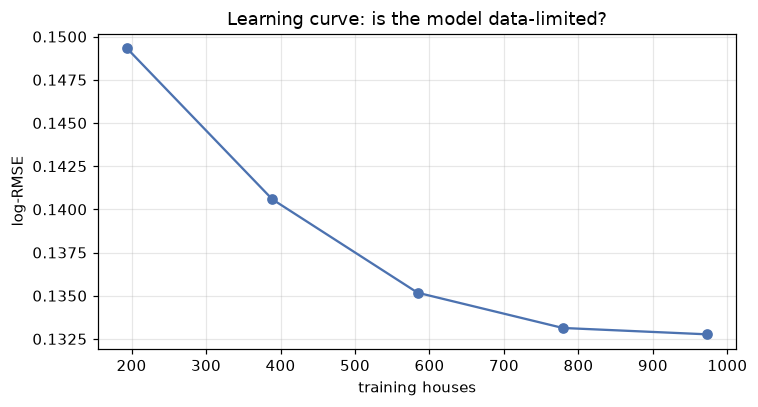

In [26]:
sizes = [point[0] for point in curve]
errors = [point[1] for point in curve]

fig, axis = plt.subplots(figsize=(7, 3.8))
axis.plot(sizes, errors, marker="o", color="#4C72B0")
axis.set_xlabel("training houses")
axis.set_ylabel("log-RMSE")
axis.set_title("Learning curve: is the model data-limited?")
fig.tight_layout()
plt.show()

**The curve has flattened.** Going from 194 to 584 training houses buys
0.014 of log-RMSE; going from 779 to 973 buys 0.0003 — effectively nothing.
The model has learned what this feature set can express.

That answers the practical question directly: collecting more Ames sales
would not help. Further accuracy has to come from **better features**, not
more rows, which points straight back at the ordinal quality columns
discarded by one-hot encoding.

It also explains the ablation in section 5. If the model is no longer
data-limited, adding nine features derived from columns it already has is
unlikely to move it — and it did not.

---

## 9. The model that gets deployed

The winner is refitted on all 1460 rows — cross-validation chose the model,
but holding rows back from the shipped one would only make it worse — and
exported as a single artifact.

The artifact itself is produced by `python -m src.train`, which repeats the
comparison above and writes `models/model.pkl` and `models/features.pkl`.
This notebook explains and justifies the decision; the script produces the
file. Keeping those separate means there is exactly one path to the model
that gets served, and no chance of the notebook and the pipeline exporting
two different things.

The cell below rebuilds the same estimator in memory so the rest of this
section can inspect it, and deliberately does not save it.

In [27]:
final_model = build_model("xgboost").fit(features, target)

encoded_columns = feature_names(final_model)
raw_columns = [c for c in features.columns if c != CONFIG.id_column]

print(f"raw columns expected : {len(raw_columns)}")
print(f"encoded columns      : {len(encoded_columns)}")
print(f"regressor            : {type(final_model.regressor_[-1]).__name__}")

raw columns expected : 79
encoded columns      : 325
regressor            : XGBRegressor


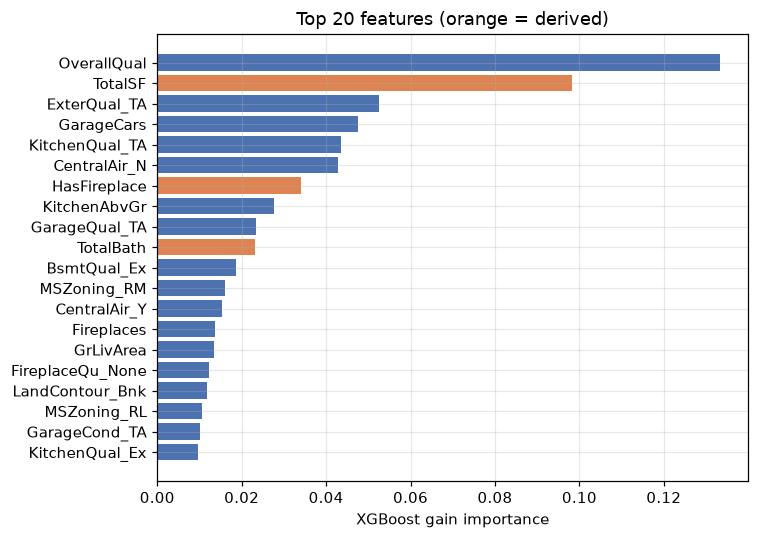

In [28]:
importances = pd.Series(
    final_model.regressor_[-1].feature_importances_, index=encoded_columns
).sort_values(ascending=False).head(20)

fig, axis = plt.subplots(figsize=(7, 5))
colours = [
    "#DD8452" if name in new_columns else "#4C72B0" for name in importances.index
]
axis.barh(importances.index[::-1], importances.values[::-1], color=colours[::-1])
axis.set_xlabel("XGBoost gain importance")
axis.set_title("Top 20 features (orange = derived)")
fig.tight_layout()
plt.show()

In [29]:
predictions = final_model.predict(test_frame[raw_columns])

print(f"{len(predictions)} houses scored from test.csv")
print(f"range   : ${predictions.min():,.0f} to ${predictions.max():,.0f}")
print(f"mean    : ${predictions.mean():,.0f}")
print(f"training mean for comparison: ${target.mean():,.0f}")

1459 houses scored from test.csv
range   : $43,386 to $533,462
mean    : $177,945
training mean for comparison: $180,921


### What part two receives

`models/model.pkl` holds the **entire** estimator. It accepts a raw
dataframe and returns sale prices in dollars; cleaning, feature engineering,
encoding and the log transform all happen inside it. The serving layer needs
no knowledge of any of them, and there is no way for training and serving to
preprocess differently — a common and expensive class of production bug.

`models/features.pkl` holds the contract:

- `raw_columns` — the 79 columns a request must supply
- `encoded_columns` — the 325 the regressor was fitted on

Note that both variants of the model require the same 79 columns. The
derived features are computed *inside* the pipeline and are never supplied
by the caller, so the ablation in section 4 has no bearing on the API
surface.

---

## 10. How wrong is it, and where?

A single error number hides everything a user needs to know. Two houses can
share a log-RMSE and be wrong in completely different ways.

Every figure below uses **out-of-fold** predictions: each house is scored by
a model that never saw it during training. In-sample residuals would look
far better and mean nothing.

In [30]:
oof = pd.Series(index=features.index, dtype=float)

splitter = KFold(
    n_splits=CONFIG.n_splits, shuffle=True, random_state=CONFIG.random_seed
)

for train_index, valid_index in splitter.split(features):
    model = build_model("xgboost")
    model.fit(features.iloc[train_index], target.iloc[train_index])
    oof.iloc[valid_index] = model.predict(features.iloc[valid_index])

residual = oof - target
relative = residual / target

print(f"out-of-fold predictions for all {len(oof)} houses")
print(f"median absolute error : ${residual.abs().median():,.0f}")
print(f"median relative error : {relative.abs().median():.1%}")

out-of-fold predictions for all 1460 houses
median absolute error : $9,012
median relative error : 5.6%


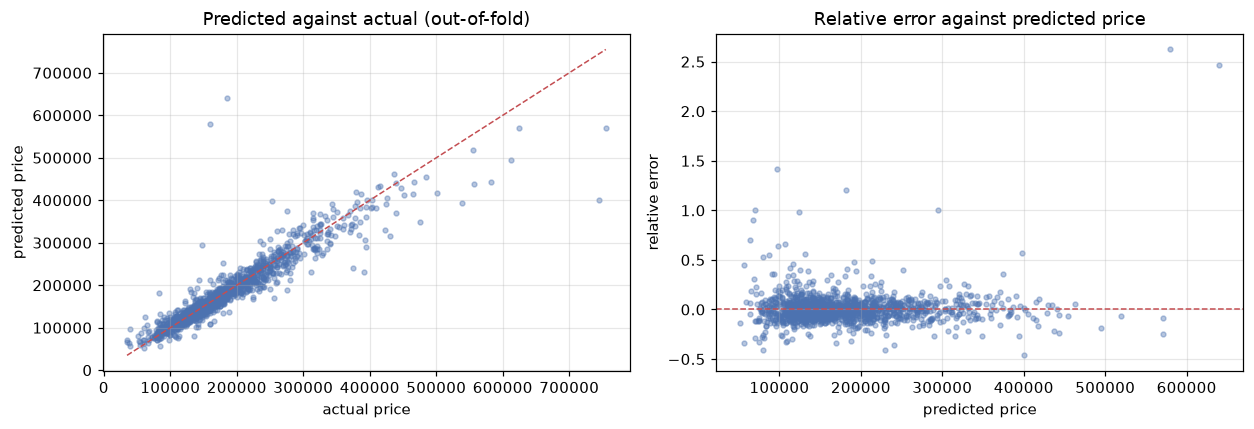

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

limits = [target.min(), target.max()]
axes[0].scatter(target, oof, s=10, alpha=0.4, color="#4C72B0")
axes[0].plot(limits, limits, color="#C44E52", linestyle="--", linewidth=1)
axes[0].set_xlabel("actual price")
axes[0].set_ylabel("predicted price")
axes[0].set_title("Predicted against actual (out-of-fold)")

axes[1].scatter(oof, relative, s=10, alpha=0.4, color="#4C72B0")
axes[1].axhline(0, color="#C44E52", linestyle="--", linewidth=1)
axes[1].set_xlabel("predicted price")
axes[1].set_ylabel("relative error")
axes[1].set_title("Relative error against predicted price")

fig.tight_layout()
plt.show()

The model tracks the diagonal closely up to roughly $300,000 and then starts
to under-predict: the most expensive houses come out cheaper than they sold
for. That is the log target doing its job in the direction we asked for — it
protects the many ordinary houses at the cost of the few extreme ones — and
it is also a data problem, since there are simply fewer expensive houses to
learn from.

In [32]:
segment = pd.qcut(target, 5, labels=["cheapest", "low", "mid", "high", "priciest"])

by_segment = pd.DataFrame(
    {
        "houses": target.groupby(segment).size(),
        "median price": target.groupby(segment).median().round(0),
        "median abs error": residual.abs().groupby(segment).median().round(0),
        "median rel error": relative.abs().groupby(segment).median(),
        "bias": relative.groupby(segment).median(),
    }
)
by_segment["median rel error"] = by_segment["median rel error"].map("{:.1%}".format)
by_segment["bias"] = by_segment["bias"].map("{:+.1%}".format)

by_segment

,houses,median price,median abs error,median rel error,bias
SalePrice,,,,,
cheapest,295,106500.0,7774.0,7.6%,+4.0%
low,294,135980.0,6401.0,4.6%,-0.5%
mid,287,163500.0,7886.0,4.8%,-1.5%
high,295,199900.0,9980.0,4.8%,-1.2%
priciest,289,279500.0,19748.0,6.7%,-2.4%


### What this means for the product

Relative error is fairly flat across price bands — which is exactly what the
log target was chosen to achieve — but the **bias** column tells the more
useful story: the cheapest houses are over-valued and the priciest
under-valued. A model trained on a log target regresses towards the middle,
and anyone quoting a price for a $500,000 house should know it will read low.

### An honest interval to quote

A single number invites false precision. The out-of-fold relative errors
give an empirical interval directly, with no distributional assumption.

In [33]:
lower, upper = np.percentile(relative, [10, 90])
inside = ((relative >= lower) & (relative <= upper)).mean()

print(f"80% of out-of-fold predictions fall between {lower:+.1%} and {upper:+.1%}")
print(f"(check: {inside:.1%} of houses land inside that band)")
print()
print("So a $200,000 prediction is best quoted as roughly")
print(f"   ${200_000 * (1 + lower):,.0f} to ${200_000 * (1 + upper):,.0f}")
print()
print("Worst five out-of-fold errors:")

worst = relative.abs().nlargest(5).index
print(
    pd.DataFrame(
        {
            "actual": target[worst].round(0),
            "predicted": oof[worst].round(0),
            "relative": relative[worst].map("{:+.0%}".format),
            "SaleCondition": features.loc[worst, "SaleCondition"],
            "GrLivArea": features.loc[worst, "GrLivArea"],
        }
    ).to_string()
)

80% of out-of-fold predictions fall between -11.2% and +11.9%
(check: 80.0% of houses land inside that band)

So a $200,000 prediction is best quoted as roughly
   $177,619 to $223,818

Worst five out-of-fold errors:
      actual  predicted relative SaleCondition  GrLivArea
1298  160000   579700.0    +262%       Partial       5642
523   184750   639750.0    +246%       Partial       4676
30     40000    96862.0    +142%        Normal       1317
632    82500   182022.0    +121%        Family       1411
495    34900    70060.0    +101%       Abnorml        720


Two of the five worst misses are the unfinished `Partial` sales from
section 3 — the houses we deliberately kept, and the price of not curating
the data to flatter the metric.

The other three are a different failure and more interesting. They are
*cheap* houses predicted far too high: one sold for $40,000 and was valued
near $97,000, another sold for $34,900. At that end of the market the price
is often set by circumstances the features cannot see — a family transfer,
a forced sale, a property in poor condition — and `SaleCondition` shows
`Family` and `Abnorml` for exactly those rows. The model has no way to know
how far below market such a sale will land.

This is a real limitation of the product, not a modelling defect: for
non-market transactions, no set of house attributes predicts the agreed
price.

### How fast is a prediction?

The model is behind a live API, so latency is part of the product.

In [34]:
import time

sample = features.head(1)
final_model.predict(sample)  # warm the first call

single = []
for _ in range(50):
    started = time.perf_counter()
    final_model.predict(sample)
    single.append((time.perf_counter() - started) * 1000)

batch = features.head(100)
started = time.perf_counter()
final_model.predict(batch)
batch_ms = (time.perf_counter() - started) * 1000

print(f"one house   : {np.median(single):.1f} ms median, "
      f"{np.percentile(single, 95):.1f} ms at the 95th percentile")
print(f"100 houses  : {batch_ms:.0f} ms total, {batch_ms / 100:.2f} ms per house")
print()
print("Model time only, measured in this process. The deployed service also")
print("pays a network round trip and a Delta Lake write, neither of which is")
print("measured here — quote this as a floor, not as end-to-end latency.")

one house   : 76.1 ms median, 82.5 ms at the 95th percentile
100 houses  : 84 ms total, 0.84 ms per house

Model time only, measured in this process. The deployed service also
pays a network round trip and a Delta Lake write, neither of which is
measured here — quote this as a floor, not as end-to-end latency.


---

## 11. Model card

**What it does.** Estimates the sale price of a single-family home in Ames,
Iowa, from 79 descriptive attributes. Returns one number in US dollars.

**Trained on.** 1460 residential sales in Ames, Iowa, recorded 2006–2010
(Kaggle *Home Data for ML Course*, derived from De Cock's Ames Housing
dataset).

**Intended use.** A first-pass valuation estimate, and a teaching example of
an end-to-end ML deployment. Suitable for ranking or screening properties.

**Not suitable for.** Any market other than Ames, Iowa. Any period far from
2006–2010. Commercial property, land, or new construction sold before
completion. Legal, tax or lending decisions, where a licensed appraisal is
required.

**Known limitations.**

- Validation shuffles across years. Section 8 tests this directly and finds
  no inflation, but that test rests on a single partial year of 175 sales
  and is therefore weak evidence rather than a clean bill of health.
- Non-market sales — `Partial`, `Family`, `Abnorml` — are the largest
  errors and are not predictable from house attributes.
- Predictions regress towards the middle: cheap houses read high and
  expensive houses read low (section 10).
- Unfinished `Partial` sales are the largest errors, by design.
- The ordered quality columns are one-hot encoded, discarding their order.

**Performance.** Under shuffled five-fold cross-validation: 0.127 log-RMSE,
about $14,900 mean absolute error, 8.5% mean absolute percentage error.
Out-of-fold, the *median* relative error is 5.6% and the *median* absolute
error $9,000 — the medians are the better guide to a typical house, since
the means are pulled up by the non-market sales described in section 10.
Trained on data up to 2009 and scored on 2010 it reaches 0.106, giving no
sign that the shuffled figure is inflated.

### Monitoring, now that it is live

The API writes every prediction to Delta Lake with its inputs, timestamp
and a hash of the model file. That table is not just an audit log — it is
the raw material for noticing when this model stops being right:

- **Input drift.** Compare the distribution of incoming `GrLivArea`,
  `Neighborhood` and `YearBuilt` against the training data. A shift means
  the model is being asked about houses it never learned from.
- **Prediction drift.** The distribution of predicted prices should be
  stable week to week. A jump usually means an upstream input changed, not
  that the market moved overnight.
- **Ground truth, when it arrives.** Actual sale prices become available
  months later. Joining them back on to logged predictions is the only real
  measure of production accuracy, and the `model_version` hash makes it
  possible to attribute each error to the exact artifact that produced it.
- **Retraining trigger.** Once realised error exceeds the 10–90% band
  established in section 10 for a sustained period, retrain — one command,
  about 25 seconds.

---

## Summary

1. `SalePrice` is right-skewed; the model trains on `log1p` and is scored
   with log-RMSE, which weights a proportional error equally at every price.
2. Missing values carry three different meanings, and conflating them
   invents basements and garages. Only genuinely unknown values are imputed,
   and those statistics are learned from the training fold alone.
3. The famous large-cheap houses are unfinished `Partial` sales. Dropping
   them improves the score, but only because it removes them from the test
   folds too. We keep them and let `SaleCondition` carry the information.
4. Nine derived features encode relationships an appraiser would use.
5. Measured with a paired design, those features produce **no demonstrable
   accuracy gain**. They are kept for interpretability, and we say so rather
   than claiming an improvement the data does not support.
6. XGBoost is selected at log-RMSE 0.127, roughly $15,000 mean absolute
   error — though its lead over LightGBM is inside the noise, and Ridge on
   the same features is not far behind.
7. Randomised hyperparameter search produced no measurable improvement over
   the hand-picked configuration, so the defaults ship.
8. The exported artifact is a complete pipeline, ready for the FastAPI
   service in part two.

### What we would do next

Three of the four levers we pulled moved the score by less than the fold
spread: the derived features, the hyperparameter search, and the choice
between XGBoost and LightGBM. Only the step up from a linear model cleared
it. And the learning curve says more data would not help either.

Taken together, that is a clear instruction: the remaining gains are in how
the inputs are represented, not in the model or the volume.

- **Ordinal quality columns.** `ExterQual`, `KitchenQual`, `HeatingQC` and
  friends run `Ex > Gd > TA > Fa > Po`. One-hot encoding throws that order
  away and makes the model rediscover it. This is the largest untouched
  gain.
- **Neighbourhood-aware imputation** for `LotFrontage`, which is currently
  filled with a single global median.
- **Repeated cross-validation.** Three repeats would give fifteen paired
  folds instead of five and narrow every interval in this notebook by
  roughly a factor of 1.7 — enough to resolve differences we currently
  cannot.